# Embedding feasibility

Two independent studies on the v2 aggregated metadata (`tmp/115-...__AGGREGATED.jsonl`, 30 GB), restricted to `tp ∈ {article, ad}` (~64 M items).

**Research 1 — How big is the cohort?**  Count `article`, `ad`, and `article+ad` over a 4×4 sweep of OCRQA × min char-length filters.

**Research 2 — How big / how fast is the Solr index?**  For one canonical cohort, estimate index size and end-to-end query latency in a Solr 10.X deployment, sweeping the **Matryoshka-native** dimensions (`768, 512, 256, 128` — all free truncations of the `gte-multilingual-base` CLS vector) × **Solr-deployable precisions** (`fp32` = `vectorEncoding=FLOAT32`, `int8` = `vectorEncoding=BYTE`).

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 11,
})

ARTAD = Path('aggregated_summary_artad.csv')
FIGURES_DIR = Path('figures'); FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Research 1 — cohort sweep axes
OCRQA_THRESHOLDS = ['NaN',0, 0.5, 0.6, 0.7, 0.8]
LEN_THRESHOLDS   = [0, 200, 400, 600, 800]

# Research 2 — Solr index estimator axes
# Matryoshka native truncations on gte-multilingual-base ("Elastic Dense Embedding", any d in [128, 768])
DIMS = [768, 512, 256, 128]
# Solr 9.x vectorEncoding accepts only FLOAT32 or BYTE; BBQ (1-bit) is Lucene/Elasticsearch-only today.
BYTES_PER_DIM = {'fp32': 4, 'int8': 1}

# Lucene HNSW per-vector RAM:  ~1.1 × (bytes_per_dim × d + 8 × M)  (vectors + graph edges + codec overhead)
# Sources: Lucene 9.9 Lucene99HnswVectorsFormat javadoc, Lantern HNSW calculator blog.
HNSW_M = 16            # Solr/Lucene default
HNSW_OVERHEAD = 1.1    # +10 % for graph layers + codec metadata

# Latency calibration anchor — Burgmans (Solr 9.7, default config): 2.6 M × 768d × fp32 → ~10 ms HNSW p50.
# Hop count scales ~log(N); per-hop distance cost scales ~linearly with bytes_per_dim × d.
LAT_ANCHOR_N, LAT_ANCHOR_LAT_MS = 2.6e6, 10.0

# Query-encoder forward pass on CPU for a 768d sentence-transformer (sentence-transformers / Burgmans / Sease).
ENCODER_FWD_MS = (10, 40)

# Canonical cohort for Research 2 (single point in the Research-1 sweep)
CANON_OCRQA = 0.6
CANON_LEN   = 400


def human_bytes(n: float) -> str:
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if n < 1024:
            return f'{n:.2f} {unit}'
        n /= 1024
    return f'{n:.2f} PB'


def fmt_lat(s: float) -> str:
    if s < 1e-3: return f'{s*1e6:.1f} µs'
    if s < 1:    return f'{s*1e3:.1f} ms'
    return f'{s:.2f} s'

In [11]:
artad = pd.read_csv(ARTAD)
artad_total = int(artad['n'].sum())
print(f'rows in summary : {len(artad):,}')
print(f'article+ad items: {artad_total:,}')
print(artad.groupby('tp')['n'].sum().to_string())

rows in summary : 5,155
article+ad items: 63,992,201
tp
ad         18516758
article    45475443


In [12]:
# Cumulative drop ladder — quantify what's filtered out before the Research-1 sweep starts.
# 'NA', '<0.5', '<200' buckets are emitted by aggregate_artad.py and present in the parquet;
# the count_for() helper defined below silently drops these three categories.
_total   = int(artad['n'].sum())
_n_NA    = int(artad.loc[artad['ocrqa_bucket'].isna(),    'n'].sum())
_n_lt05  = int(artad.loc[artad['ocrqa_bucket'] == '<0.5',  'n'].sum())
# After dropping NA and <0.5: rows with ocrqa in {0.5-0.6, 0.6-0.7, 0.7-0.8, >=0.8}
_post    = artad[artad['ocrqa_bucket'].isin(['0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'])]
_n_lt200 = int(_post.loc[_post['len_bucket'] == '<200', 'n'].sum())
# Canonical cohort: ocrqa >= 0.6 AND len >= 400
_canon   = int(artad[
    artad['ocrqa_bucket'].isin(['0.6-0.7', '0.7-0.8', '>=0.8'])
    & artad['len_bucket'].isin(['400-600', '600-800', '>=800'])
]['n'].sum())

print(f'raw article+ad rows in parquet      : {_total:>12,}')
print(f'  drop NA-OCRQA                     : {-_n_NA:>12,}  ({_n_NA/_total:6.1%})')
print(f'  drop <0.5 OCRQA                   : {-_n_lt05:>12,}  ({_n_lt05/_total:6.1%})')
print(f'  drop <200 chars (post-OCRQA≥0.5)  : {-_n_lt200:>12,}  ({_n_lt200/_total:6.1%})')
print(f'canonical cohort (≥{CANON_OCRQA}, ≥{CANON_LEN})        : {_canon:>12,}  ({_canon/_total:6.1%} of raw)')

raw article+ad rows in parquet      :   63,992,201
  drop NA-OCRQA                     :   -9,117,775  ( 14.2%)
  drop <0.5 OCRQA                   :     -732,258  (  1.1%)
  drop <200 chars (post-OCRQA≥0.5)  :   -5,768,065  (  9.0%)
canonical cohort (≥0.6, ≥400)        :   38,689,459  ( 60.5% of raw)


## Research 1 — cohort sizes

Cumulative thresholds from the pre-bucketed summary. `NA` ocrqa rows are excluded throughout (no quality signal → not search-worthy).

In [13]:
OCRQA_GEQ = {
    "NaN": [None, "<0.5", '0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'],
    0: ["<0.5", '0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'],
    0.5: ['0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'],
    0.6: ['0.6-0.7', '0.7-0.8', '>=0.8'],
    0.7: ['0.7-0.8', '>=0.8'],
    0.8: ['>=0.8'],
}
LEN_GEQ = {
    0: ['<200', '200-400', '400-600', '600-800', '>=800'],
    200: ['200-400', '400-600', '600-800', '>=800'],
    400: ['400-600', '600-800', '>=800'],
    600: ['600-800', '>=800'],
    800: ['>=800'],
}


def count_for(ocrqa_t: float, len_t: int, tp: str | None = None, df: pd.DataFrame = None) -> int:
    d = artad if df is None else df
    sub = d[d['ocrqa_bucket'].isin(OCRQA_GEQ[ocrqa_t])
            & d['len_bucket'].isin(LEN_GEQ[len_t])]
    if tp is not None:
        sub = sub[sub['tp'] == tp]
    return int(sub['n'].sum())


def grid(tp: str | None = None) -> pd.DataFrame:
    return pd.DataFrame(
        {f'len ≥ {lt}': [count_for(qt, lt, tp=tp) for qt in OCRQA_THRESHOLDS] for lt in LEN_THRESHOLDS},
        index=[f'ocrqa ≥ {qt}' for qt in OCRQA_THRESHOLDS],
    )


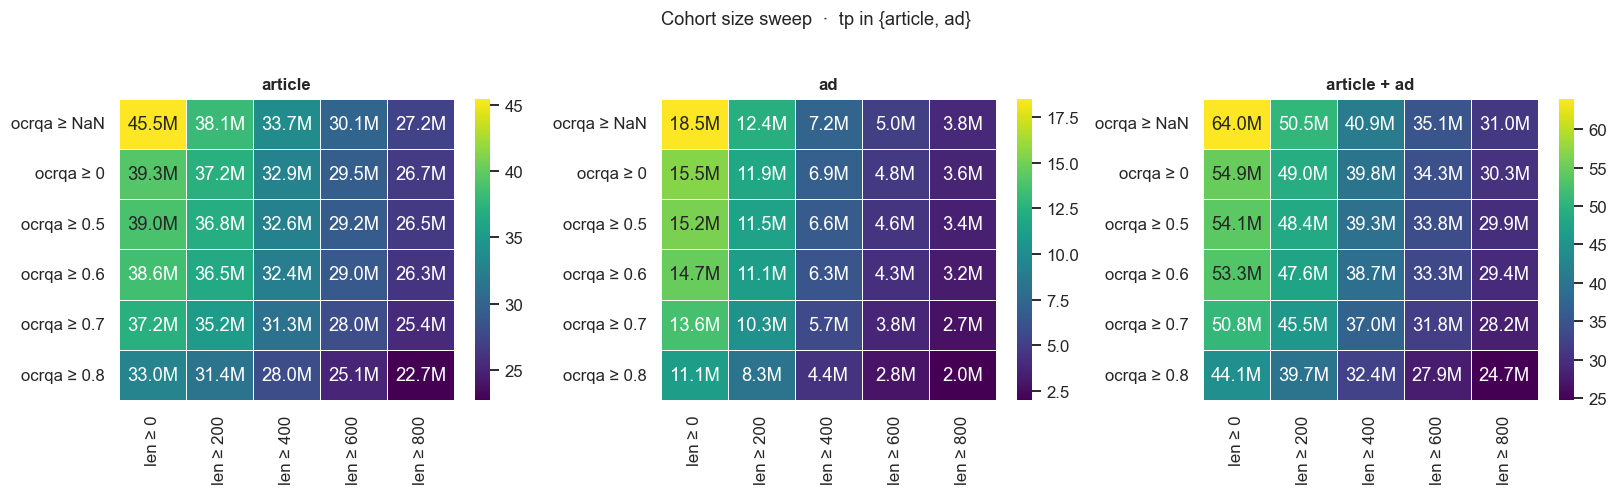

,len ≥ 0,len ≥ 200,len ≥ 400,len ≥ 600,len ≥ 800
ocrqa ≥ NaN,63992201,50531969,40911011,35116597,31010221
ocrqa ≥ 0,54874426,49019467,39807743,34251264,30296498
ocrqa ≥ 0.5,54142168,48374103,39279446,33791140,29884189
ocrqa ≥ 0.6,53260251,47633501,38689459,33289127,29440729
ocrqa ≥ 0.7,50817117,45532163,36998573,31839690,28153745
ocrqa ≥ 0.8,44110110,39710075,32377659,27911409,24700317


In [14]:
g_article = grid('article')
g_ad      = grid('ad')
g_both    = grid()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, g, title in zip(axes, [g_article, g_ad, g_both], ['article', 'ad', 'article + ad']):
    annot = (g / 1e6).map(lambda x: f'{x:.1f}M')
    sns.heatmap(g / 1e6, annot=annot.values, fmt='', cmap='viridis', linewidths=0.4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Cohort size sweep  ·  tp in {article, ad}', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cohort_sweep.png', bbox_inches='tight')
plt.show()

g_both

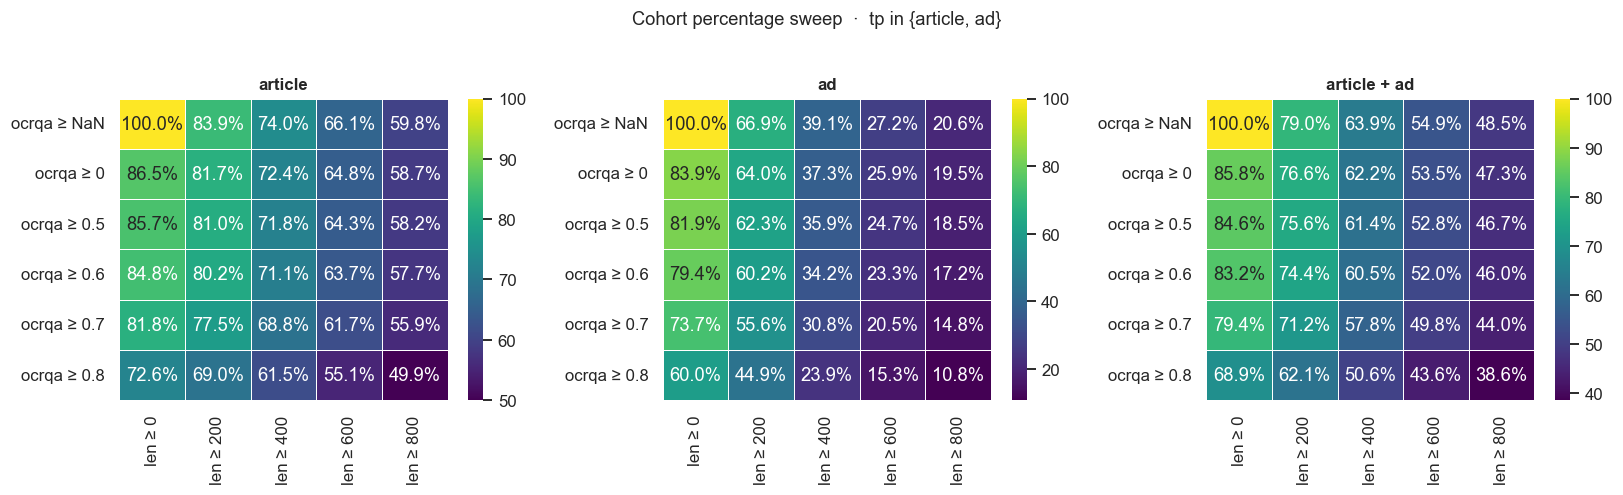

,len ≥ 0,len ≥ 200,len ≥ 400,len ≥ 600,len ≥ 800
ocrqa ≥ NaN,100.000000,78.965824,63.931245,54.876370,48.459376
ocrqa ≥ 0,85.751740,76.602252,62.207179,53.524122,47.344047
ocrqa ≥ 0.5,84.607448,75.593748,61.381614,52.805091,46.699736
ocrqa ≥ 0.6,83.229284,74.436416,60.459647,52.020600,46.006745
ocrqa ≥ 0.7,79.411422,71.152675,57.817316,49.755579,43.995588
ocrqa ≥ 0.8,68.930447,62.054554,50.596258,43.616892,38.598949


In [15]:
def grid(tp: str | None = None) -> pd.DataFrame:
    nb_total = int(artad[artad['tp'] == tp]['n'].sum()) if tp is not None else int(artad['n'].sum())
    return pd.DataFrame(
        {f'len ≥ {lt}': [100*(count_for(qt, lt, tp=tp)/nb_total) for qt in OCRQA_THRESHOLDS] for lt in LEN_THRESHOLDS},
        index=[f'ocrqa ≥ {qt}' for qt in OCRQA_THRESHOLDS],
    )

g_article = grid('article')
g_ad      = grid('ad')
g_both    = grid()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, g, title in zip(axes, [g_article, g_ad, g_both], ['article', 'ad', 'article + ad']):
    annot = (g).map(lambda x: f'{x:.1f}%')
    sns.heatmap(g, annot=annot.values, fmt='', cmap='viridis', linewidths=0.4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Cohort percentage sweep  ·  tp in {article, ad}', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cohort_percentage.png', bbox_inches='tight')
plt.show()

g_both

## Research 2 — Solr index size and HNSW latency estimator

For the canonical cohort `(ocrqa ≥ 0.6, len ≥ 400, tp ∈ {article, ad})`, sweep the embedding format Solr will actually run:

- **Index size** = `N × 1.1 × (bytes_per_dim × d + 8 × M)` (Lucene HNSW formula, default `M = 16`).
- **HNSW p50 latency** = anchored at Burgmans 2.6 M × 768d × fp32 ≈ 10 ms, scaled by `log(N)/log(2.6 M)` (hop count) × `(bytes_per_dim × d) / (4 × 768)` (per-hop distance cost).
- **End-to-end p50** = HNSW + a 10–40 ms CPU encoder forward pass.

Change `CANON_OCRQA` / `CANON_LEN` in cell 2 to re-target.

> **`gte-multilingual-base` is Matryoshka-trained** ("Elastic Dense Embedding" in the Alibaba model card). Any `d ∈ [128, 768]` is a free truncation of the CLS vector — `embeddings = outputs.last_hidden_state[:, 0][:dimension]`. **No PCA**, no calibration set, no separate query-time projection. The MTEB English ablation in the model card shows performance is approximately flat down to 512d and degrades gracefully below; recall impact at 256d / 128d should be measured on the Impresso eval set, but the option is **first-class on this model**.

> **Estimator scope.** Memory numbers are formula-derived (Lucene 9.9 `Lucene99HnswVectorsFormat`); latency numbers are extrapolations from one published Solr benchmark (Burgmans 2.6 M default config) and assume `efSearch ≈ 100`, no force-merge, single-segment-traversal-cost-equivalent. They are **planning numbers, not SLOs** — replace with measured QPS once a real index lands. The `binary` (BBQ, 1-bit) row is intentionally absent because Solr 9.x cannot ingest it; it is discussed in Research 3.

In [16]:
N = count_for(CANON_OCRQA, CANON_LEN)
print(f'cohort N (ocrqa ≥ {CANON_OCRQA}, len ≥ {CANON_LEN}): {N:,} items')


def hnsw_bytes_per_vec(d: int, precision: str) -> float:
    """Lucene 9.9 HNSW: vectors + graph edges + ~10% codec overhead."""
    return HNSW_OVERHEAD * (BYTES_PER_DIM[precision] * d + 8 * HNSW_M)


def index_size_gb(n: int, d: int, precision: str) -> float:
    return n * hnsw_bytes_per_vec(d, precision) / 1e9


def est_hnsw_ms(n: int, d: int, precision: str) -> float:
    """HNSW p50 ≈ anchor × log(N)/log(N_anchor) × (bytes_per_dim·d) / (bytes_anchor·d_anchor)."""
    log_scale  = np.log(n) / np.log(LAT_ANCHOR_N)
    cost_ratio = (BYTES_PER_DIM[precision] * d) / (4 * 768)   # vs Burgmans fp32/768d anchor
    return LAT_ANCHOR_LAT_MS * log_scale * cost_ratio


rows = []
for d in DIMS:
    for prec in BYTES_PER_DIM:
        size_gb = index_size_gb(N, d, prec)
        hnsw_ms = est_hnsw_ms(N, d, prec)
        e2e_lo  = hnsw_ms + ENCODER_FWD_MS[0]
        e2e_hi  = hnsw_ms + ENCODER_FWD_MS[1]
        rows.append({
            'dim': d, 'precision': prec,
            'index_size_GB': size_gb,
            'hnsw_p50_ms':   hnsw_ms,
            'e2e_p50_ms':    e2e_lo,    # encoder lower-bound
            'e2e_p99_ms':    e2e_hi,    # encoder upper-bound stacked on HNSW p50
        })
estimator = pd.DataFrame(rows).set_index(['dim', 'precision'])

display = estimator.copy()
display['index_size_GB'] = display['index_size_GB'].map(lambda v: f'{v:>6.1f} GB')
display['hnsw_p50_ms']   = display['hnsw_p50_ms'].map(lambda v: f'{v:>5.1f} ms')
display['e2e_p50_ms']    = display.apply(lambda r: f'{r.e2e_p50_ms:>5.1f}–{r.e2e_p99_ms:>5.1f} ms', axis=1)
display = display.drop(columns=['e2e_p99_ms']).rename(columns={
    'index_size_GB': 'index size (formula)',
    'hnsw_p50_ms':   'HNSW p50 (calibrated)',
    'e2e_p50_ms':    'end-to-end (+enc 10–40 ms)',
})

print(f'\nSolr index estimator  ·  N = {N/1e6:.1f} M items  ·  M = {HNSW_M}, efSearch ≈ 100, no force-merge')
print(display.to_string())

cohort N (ocrqa ≥ 0.6, len ≥ 400): 38,689,459 items

Solr index estimator  ·  N = 38.7 M items  ·  M = 16, efSearch ≈ 100, no force-merge
              index size (formula) HNSW p50 (calibrated) end-to-end (+enc 10–40 ms)
dim precision                                                                      
768 fp32                  136.2 GB               11.8 ms              21.8– 51.8 ms
    int8                   38.1 GB                3.0 ms              13.0– 43.0 ms
512 fp32                   92.6 GB                7.9 ms              17.9– 47.9 ms
    int8                   27.2 GB                2.0 ms              12.0– 42.0 ms
256 fp32                   49.0 GB                3.9 ms              13.9– 43.9 ms
    int8                   16.3 GB                1.0 ms              11.0– 41.0 ms
128 fp32                   27.2 GB                2.0 ms              12.0– 42.0 ms
    int8                   10.9 GB                0.5 ms              10.5– 40.5 ms


/var/folders/4m/l5rkp4s94jg_fr07xhlzksb00000gs/T/ipykernel_28692/51405787.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


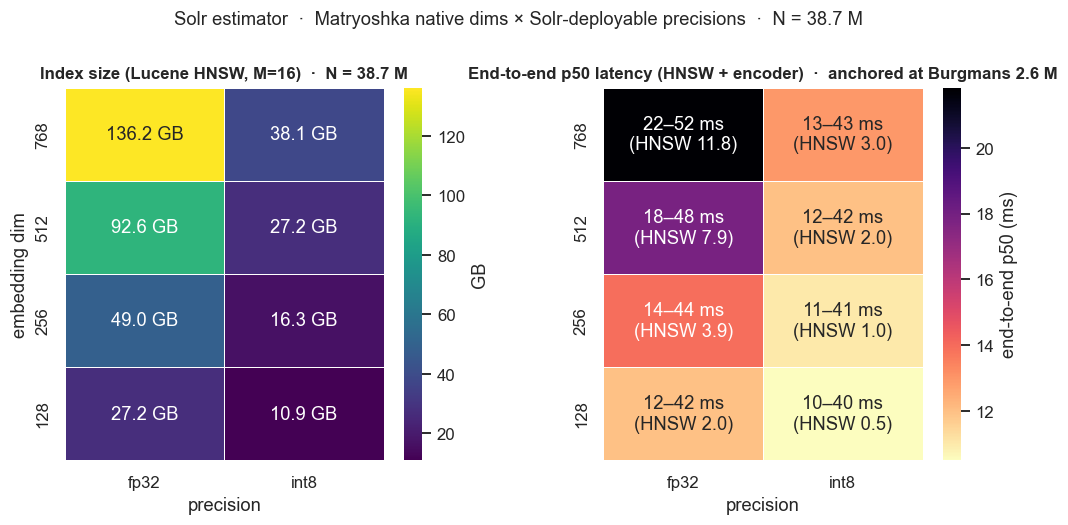

In [17]:
# Render the estimator as two side-by-side heatmaps sharing axes (rows = dim, cols = precision):
#   left  = index size in GB (Lucene HNSW formula — exact for given M)
#   right = end-to-end p50 in ms (HNSW + encoder fwd-pass; calibrated extrapolation)
size_pivot = estimator['index_size_GB'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
e2e_lo     = estimator['e2e_p50_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
e2e_hi     = estimator['e2e_p99_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
hnsw_only  = estimator['hnsw_p50_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))

size_annot = size_pivot.map(lambda v: f'{v:.1f} GB')
e2e_annot  = pd.DataFrame(
    [[f'{lo:.0f}–{hi:.0f} ms\n(HNSW {h:.1f})' for lo, hi, h in zip(e2e_lo.iloc[i], e2e_hi.iloc[i], hnsw_only.iloc[i])]
     for i in range(len(DIMS))],
    index=size_pivot.index, columns=size_pivot.columns,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={'wspace': 0.35})
sns.heatmap(size_pivot, annot=size_annot.values, fmt='', cmap='viridis',
            cbar_kws={'label': 'GB'}, linewidths=0.4, ax=axes[0])
axes[0].set_title(f'Index size (Lucene HNSW, M={HNSW_M})  ·  N = {N/1e6:.1f} M')
axes[0].set_xlabel('precision'); axes[0].set_ylabel('embedding dim')

sns.heatmap(e2e_lo, annot=e2e_annot.values, fmt='', cmap='magma_r',
            cbar_kws={'label': 'end-to-end p50 (ms)'}, linewidths=0.4, ax=axes[1])
axes[1].set_title(f'End-to-end p50 latency (HNSW + encoder)  ·  anchored at Burgmans 2.6 M')
axes[1].set_xlabel('precision'); axes[1].set_ylabel('')

fig.suptitle(f'Solr estimator  ·  Matryoshka native dims × Solr-deployable precisions  ·  N = {N/1e6:.1f} M',
             fontsize=12, y=1.04)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'solr_estimator.png', bbox_inches='tight')
plt.show()